# Ribbon edge states and bulk-boundary figure workflow

- Gabriel Wendell Celestino Rocha
---

This notebook teaches the measured finite-ribbon part of the computational bridge. All numerical work is delegated to the validated `qhe.boundary` and `qhe.viz` APIs. The notebook does not use visual inspection alone to label edge states.

## Objectives

1. define left/right edge strips and total edge participation;
2. read an edge-participation-coloured ribbon spectrum;
3. connect cumulative gap Chern numbers to side-resolved crossing orientations;
4. identify why probability profiles are a confirmation of quantitative participation, rather than a substitute for it.

In [1]:
import numpy as np
import pandas as pd

from qhe.boundary import analyze_bulk_boundary_correspondence
from qhe.models import HarperHofstadterParameters
from qhe.viz import plot_ribbon_bulk_boundary_figure
from qhe.viz.style import set_style

set_style(context="notebook", use_tex=False, grid=False)

In [2]:
params = HarperHofstadterParameters(p=1, q=3, tx=1.0, ty=1.0)
analysis = analyze_bulk_boundary_correspondence(
    params,
    bulk_nkx=41,
    bulk_nky=41,
    ribbon_lx=48,
    ribbon_nky=181,
    edge_width=4,
    edge_threshold=0.70,
    side_margin=1.0e-3,
)

band_chern = np.rint(analysis.topology.fhs.chern_numbers).astype(int)
print("> Band Chern numbers:", band_chern)

> Band Chern numbers: [-1  2 -1]


## Global gaps and oriented edge crossings

A reference energy is placed at the midpoint of every positive global bulk gap. Each ribbon crossing is retained only when its interpolated edge participation exceeds the frozen threshold. The branch slope determines orientation, while the left/right participation difference assigns the boundary.

In [3]:
rows = []
for summary in analysis.crossing_summaries:
    rows.append({
        "gap": summary.gap.index + 1,
        "energy interval": f"[{summary.gap.lower_edge:.4f}, {summary.gap.upper_edge:.4f}]",
        "C_gap": summary.gap.gap_chern_number,
        "left oriented crossings": summary.left_oriented_crossing_count,
        "right oriented crossings": summary.right_oriented_crossing_count,
        "accepted crossings": len(summary.crossings),
    })
pd.DataFrame(rows)

,gap,energy interval,C_gap,left oriented crossings,right oriented crossings,accepted crossings
0,1,"[-2.0000, -0.7321]",-1,-1,1,2
1,2,"[0.7294, 2.0020]",1,1,-1,2


## Source-controlled bulk-boundary figure

The figure below has no in-plot title. Its self-contained explanatory prose belongs in `figures/captions.md`, while the export itself is produced by the renderer.

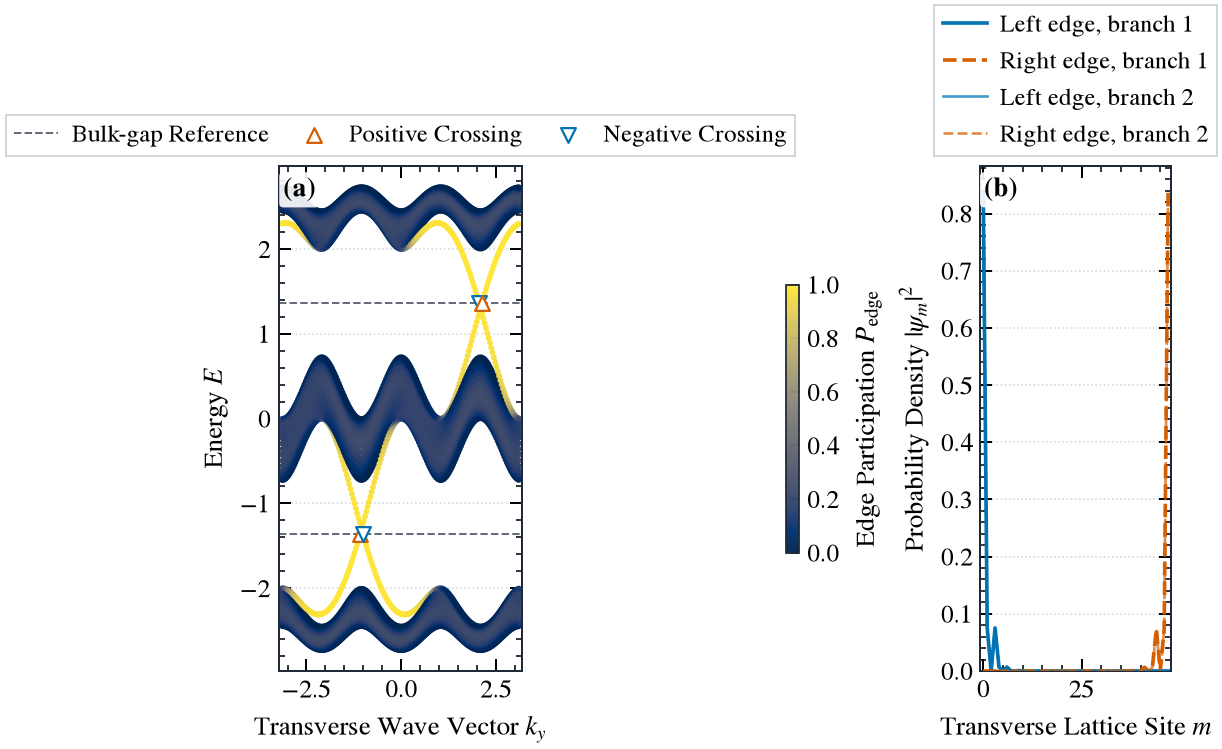

In [4]:
figure, axes = plot_ribbon_bulk_boundary_figure(analysis, context="notebook")

## Interpretation boundary

This is a static finite-ribbon diagnosis of bulk-boundary correspondence. It does not yet demonstrate real-space chirality, packet velocity, current circulation, or defect bypass.

---